# Dimensionality Reduction with PCA: Digits Dataset

## Introduction
This notebook uses Principal Component Analysis (PCA) to compress high-dimensional image-like data into fewer dimensions for visualization and analysis. The notebook is designed to teach both the mechanics of PCA and its tradeoffs.

## Project Goal
Reduce the dimensionality of the digits dataset, visualize the data in two dimensions, interpret explained variance, and test how PCA changes when the original feature set is reduced.

## Machine Learning Concepts Used
- Dimensionality Reduction
- Principal Component Analysis
- Feature Scaling
- Explained Variance
- 2D Visualization
- Variance-Based Feature Filtering

## Dataset
`sklearn.datasets.load_digits`

## Step 1: Import libraries

**What this section is doing**  
Import the scaling, PCA, and visualization tools needed for dimensionality reduction.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [1]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Step 2: Load the dataset

**What this section is doing**  
Use the digits dataset because it is high-dimensional enough for PCA to be meaningful while still remaining easy to visualize.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [2]:
data = load_digits(as_frame=True)
X = data.data.copy()
y = data.target.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (1797, 64)
y shape: (1797,)


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


## Step 3: Scale the features

**What this section is doing**  
PCA is sensitive to scale, so the feature matrix should be standardized before fitting the decomposition.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 4: Fit PCA with two components

**What this section is doing**  
The first two principal components create a compressed 2D representation that can be visualized and analyzed.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [4]:
pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X_scaled)

print("Explained variance ratio:", pca_2.explained_variance_ratio_)
print("Total explained variance:", pca_2.explained_variance_ratio_.sum())

Explained variance ratio: [0.12033916 0.09561054]
Total explained variance: 0.21594970500832805


## Step 5: Visualize the two-dimensional projection

**What this section is doing**  
A 2D PCA plot shows whether class structure is still visible after aggressive dimensionality reduction.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

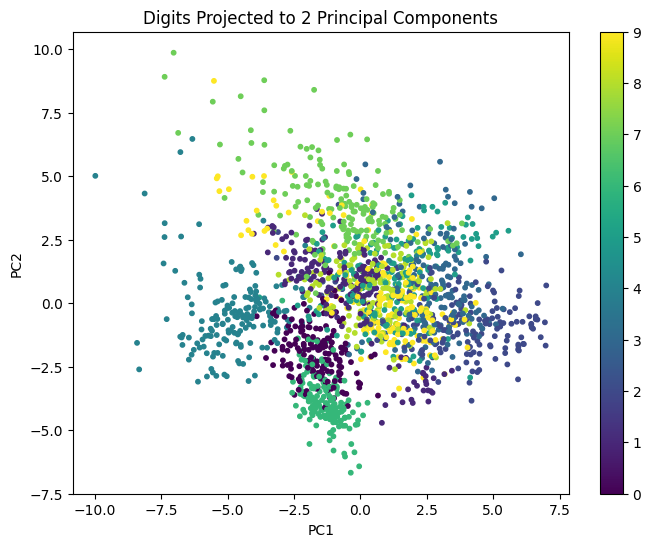

In [5]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Digits Projected to 2 Principal Components")
plt.colorbar(scatter)
plt.show()

## Step 6: Compare with more components

**What this section is doing**  
Measure how much more variance is retained when the number of principal components is increased.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [6]:
pca_20 = PCA(n_components=20, random_state=42)
X_pca_20 = pca_20.fit_transform(X_scaled)

print("Total explained variance with 20 components:", round(pca_20.explained_variance_ratio_.sum(), 4))

Total explained variance with 20 components: 0.7931


## Step 7: Refine the experiment with a smaller original feature set

**What this section is doing**  
Before PCA, reduce the original feature space using variance as a simple filter and see how much information the 2D projection retains afterward.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [7]:
selected_features = X.var().sort_values(ascending=False).head(20).index.tolist()
print("Selected original features:", selected_features[:10], "...")

X_small = X[selected_features]
X_small_scaled = StandardScaler().fit_transform(X_small)

pca_small = PCA(n_components=2, random_state=42)
X_small_pca = pca_small.fit_transform(X_small_scaled)

print("Selected-feature PCA total explained variance:", round(pca_small.explained_variance_ratio_.sum(), 4))

Selected original features: ['pixel_5_2', 'pixel_5_3', 'pixel_4_2', 'pixel_4_3', 'pixel_5_4', 'pixel_2_5', 'pixel_3_2', 'pixel_2_4', 'pixel_3_4', 'pixel_1_5'] ...
Selected-feature PCA total explained variance: 0.3678


## Step 8: Final analysis and next steps

**What this section is doing**  
Summarize what PCA preserves, what it loses, and how you would decide whether the tradeoff is worthwhile in a real project.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

### What PCA optimizes mathematically

PCA works by finding a new set of orthogonal axes, called principal components, which capture the maximum variance in the data. The first principal component accounts for the largest possible variance, and each succeeding component accounts for the highest possible variance under the constraint that it is orthogonal to the preceding components. This process essentially rotates the coordinate system to align with the directions of greatest variability in the data.

### Why explained variance matters

Explained variance quantifies how much of the original dataset's variability is captured by the principal components. A higher explained variance means that the principal components retain more of the original information.

In our case:
- With 2 components, the total explained variance was **0.2159**, meaning only about 21.6% of the total variance in the `digits` dataset is captured by the first two principal components. This indicates significant information loss when reducing to just two dimensions.
- With 20 components, the total explained variance was **0.7931**, indicating that these 20 components capture about 79.3% of the total variance, which is a much better representation of the original data.

### Why a 2D plot can be useful even when it loses a lot of information

Even with a low explained variance (like 21.6% for 2 components), a 2D PCA plot can still be incredibly useful for visualization. As seen in **Step 5**, the plot for the `digits` dataset shows clusters that correspond to different digits. While there is considerable overlap, it still gives an intuitive sense of the separability and structure within the data. It helps in quickly identifying gross patterns, potential outliers, or initial class separation, which might be hard to discern in a high-dimensional space. It's a quick way to get a 'feel' for the data's inherent structure, even if it's not a perfect representation.

### Whether the smaller original feature set changed the PCA result meaningfully

In **Step 7**, we reduced the original feature set from 64 to 20 features (the top 20 most variant pixels) before applying PCA.
- The initial 2-component PCA on all 64 features (`X_scaled`) resulted in a total explained variance of **0.2159**.
- The 2-component PCA on the reduced 20 features (`X_small_scaled`) resulted in a total explained variance of **0.3678**.

This shows a significant increase in the explained variance for the 2-component PCA when starting with a smaller, more 'informative' original feature set. This suggests that the initial feature selection (based on variance) successfully removed less important features, allowing the subsequent PCA to capture a larger proportion of the remaining variance with fewer components. In this specific case, reducing the original feature set *did* meaningfully change and improve the 2D PCA result, by retaining more information from the selected features.